In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import os
import datetime
import pandas as pd
import numpy as np
from gnomepy import Strategy, LatencyModel, SchemaBase, Order, OrderExecutionReport
from gnomepy.research.oms import LimitOrderOMS
from gnomepy.research.signals.avellaneda_stoikov import AvellanedaStoikovSignal, AvellanedaStoikovModelValueRecorder
from gnomepy.backtest import (
    Backtest,
    MBPSimulatedExchange,
    StaticLatency,
    RiskAverseQueueModel,
    StaticFeeModel
)
from gnomepy.data.types import SchemaType
from gnomepy.data.cached_client import CachedMarketDataClient
from gnomepy.registry.api import RegistryClient
from gnomepy.backtest.recorder import Recorder

# Configuration
START_DATETIME = datetime.datetime(2026, 1, 15, 12, 0)
END_DATETIME = datetime.datetime(2026, 1, 18, 12, 0)
SCHEMA_TYPE = SchemaType.MBP_10
NOTIONAL = 100_000
LISTING_IDS = [1]

AV_STOIKOV_PARAMS = {
    'trade_frequency': 1,
    'volatility_window': 50,
    'volatility_half_life': 0.5,
    'gamma': 1e14,
    'order_arrival_rate': 7200,
    'max_inventory': 1.0,
    'max_spread_ticks': None,
    'min_volatility': 1e-5,
    'min_spread_bps': 0.1,
}

STRATEGY_LATENCY = StaticLatency(1_000_000)
NETWORK_LATENCY = StaticLatency(50_000_000)
ORDER_PROCESSING_LATENCY = StaticLatency(20_000_000)

In [72]:
market_data_client = CachedMarketDataClient(
    bucket="gnome-market-data-dev",
    aws_profile_name="AWSAdministratorAccess-443370708724",
)
registry_client = RegistryClient(
    api_key="9WPV7CfeqXa578yVYlxdG3kCPFzACr7YaMU0UVma",
)

In [73]:
listings = []
for listing_id in LISTING_IDS:
    result = registry_client.get_listing(listing_id=listing_id)
    if not result:
        raise ValueError(f"Unable to find listing_id: {listing_id}")
    listings.append(result[0])
    print(f"Loaded: {result[0]}")

listing = listings[0]

Loaded: Listing(listing_id=1, security_id=1, exchange_id=1, exchange_security_id='undefined', exchange_security_symbol='BTC', date_modified='2025-12-23T18:11:06.557Z', date_created='2025-12-23T18:11:06.557Z')


In [74]:
# Create simulated exchange
exchanges = {
    listing.exchange_id: {
        listing.security_id: MBPSimulatedExchange(
            fee_model=StaticFeeModel(taker_fee=0.004, maker_fee=-0.001),
            network_latency=NETWORK_LATENCY,
            order_processing_latency=ORDER_PROCESSING_LATENCY,
            queue_model=RiskAverseQueueModel()
        )
    }
}

# Create signal recorder
signal_recorder = AvellanedaStoikovModelValueRecorder(listing_ids=LISTING_IDS)

# Create signal
avellaneda_stoikov_signal = AvellanedaStoikovSignal(
    listing=listing,
    data_schema_type=SCHEMA_TYPE,
    **AV_STOIKOV_PARAMS,
    recorder=signal_recorder,
)

# Create OMS
oms = LimitOrderOMS(
    signals=[avellaneda_stoikov_signal],
    notional=NOTIONAL,
    position_aware_sizing=False,
    position_scaling_factor=0.3
)

In [75]:
class OMSStrategy(Strategy):
    """Generic strategy wrapper for OMS-based strategies."""

    def __init__(self, processing_latency: LatencyModel, oms):
        super().__init__(processing_latency)
        self.oms = oms

    def on_market_data(self, timestamp: int, data: SchemaBase, recorder: Recorder | None = None) -> list[Order]:
        return self.oms.on_market_update(timestamp, data, recorder)

    def on_execution_report(self, timestamp: int, execution_report: OrderExecutionReport, recorder: Recorder | None = None):
        self.oms.on_execution_report(timestamp, execution_report, recorder)

strategy = OMSStrategy(processing_latency=STRATEGY_LATENCY, oms=oms)

In [76]:
backtest = Backtest(
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    listing_ids=LISTING_IDS,
    schema_type=SCHEMA_TYPE,
    strategy=strategy,
    exchanges=exchanges,
    market_data_client=market_data_client,
    registry_client=registry_client
)

print("Preparing data...")
backtest.prepare_data()

print("Executing backtest...")
backtest.fully_execute()
print("Done.")

Preparing data...
Executing backtest...
Done.


In [77]:
# OMS state
print(f"Signal positions: {oms.signal_positions}")
print(f"Overall positions: {oms.positions}")

Signal positions: {<gnomepy.research.signals.avellaneda_stoikov.signal.AvellanedaStoikovSignal object at 0x363bfd590>: {1: -0.6406178642302717}}
Overall positions: {1: -0.6406178642302717}


{'total_records': np.int64(862150), 'market_buffer_usage': {1: np.float64(0.53884375)}, 'intent_buffer_usage': {1: np.float64(0.0)}, 'schema_type': 'mbp-10', 'assets': {1: {'market_record_count': 862150, 'market_timestamp_range': (1768509895681343853, 1768682159891429776), 'market_price_range': (94307.5, 95845.5)}}}


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6044.729161,-6594.005235,0.011402,174.759003,1.019375,2.144699,-0.916701,0.0,0.0


,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades,listing_id
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6044.729161,-6594.005235,0.011402,174.759003,1.019375,2.144699,-0.916701,68.105545,674.0,1


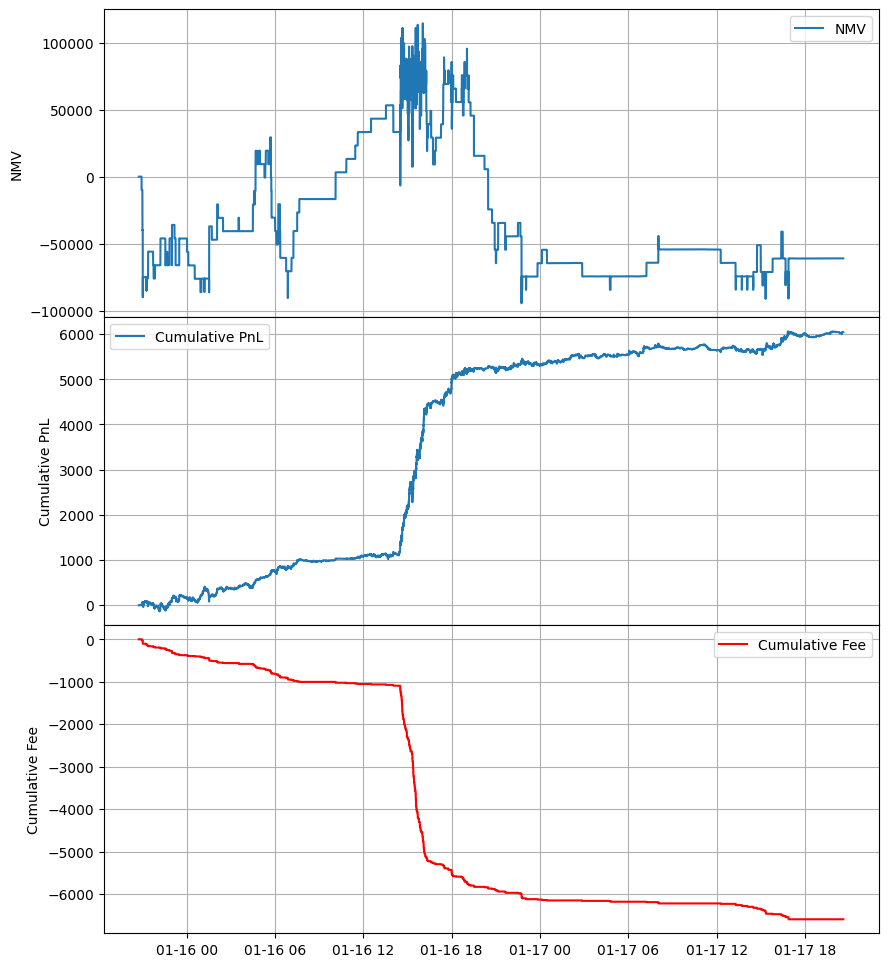

In [78]:
from gnomepy.backtest.stats.strategy import StrategyStats

print(backtest.recorder.get_summary_stats())

strat_sts = StrategyStats(
    {
        listing_id: backtest.recorder.get_record(listing_id).stats()
        for listing_id in LISTING_IDS
    },
)

display(strat_sts.summary())
display(strat_sts.listing_summary())
strat_sts.plot()

,mid_price,inventory,volatility,optimal_bid,optimal_ask,reservation_price,best_bid,best_ask,bid_confidence,ask_confidence,spread
timestamp,,,,,,,,,,,
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0
2026-01-15 20:44:57.881201602,95225.5,0.0,0.000010,95224.805556,95226.194444,95225.5,95225.0,95226.0,0.1,0.1,1.0


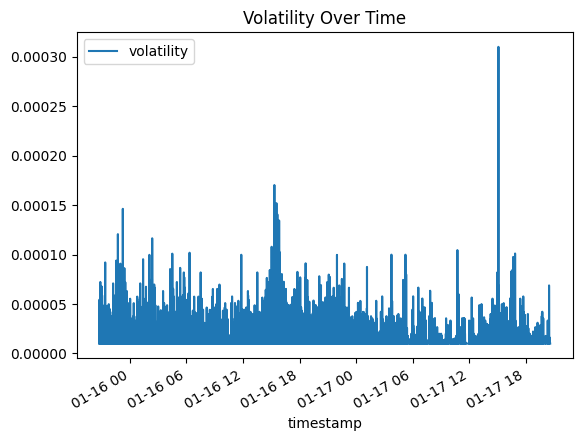

In [82]:
# Model values (requires recorder)
if avellaneda_stoikov_signal.recorder is not None:
    df = avellaneda_stoikov_signal.recorder.get_record(listing.listing_id).df
    display(df.head(20))

    df['bid_ratio'] = df['optimal_bid'] / df['best_bid']
    df['ask_ratio'] = df['optimal_ask'] / df['best_ask']
    df[['volatility']].plot(title='Volatility Over Time')

### Strategy statistics

,start_timestamp,end_timestamp,total_pnl,total_fees,sr,max_dd,volatility,win_rate,return_on_fees,trade_volume,num_trades
0,2026-01-15 20:44:55.681343853,2026-01-17 20:35:59.891429776,6044.729161,-6594.005235,0.011402,174.759003,1.019375,2.144699,-0.916701,68.105545,674.0


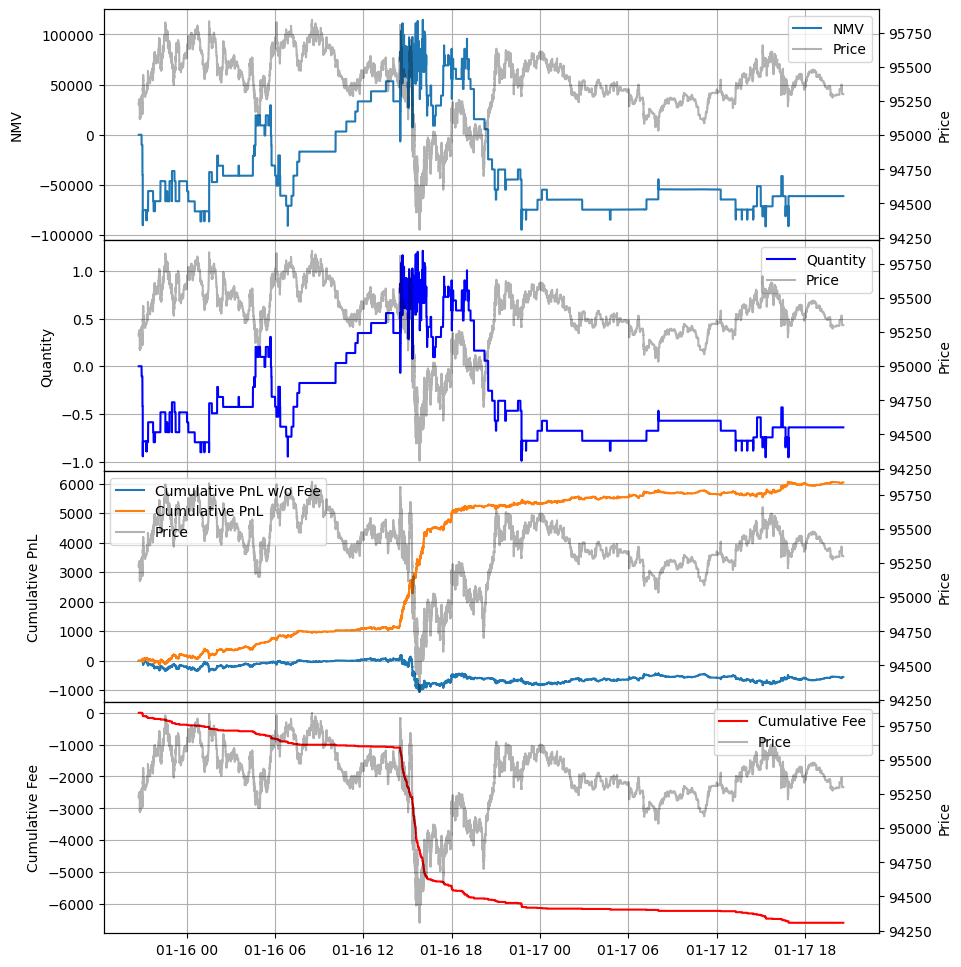

In [83]:
listing_stats = backtest.recorder.get_record(1).stats()
display(listing_stats.summary())
listing_stats.plot()

In [ ]:
# Optional: Parameter calibration
from gnomepy.research.signals.avellaneda_stoikov.calibrate import AvellanedaStoikovCalibrator

calibrator = AvellanedaStoikovCalibrator(
    market_data_client=market_data_client,
    registry_client=registry_client,
    listing_id=LISTING_IDS[0],
    start_datetime=START_DATETIME,
    end_datetime=END_DATETIME,
    schema_type=SCHEMA_TYPE,
)

results = calibrator.calibrate(
    volatility_window=1000,
    order_arrival_rate_method='spread_based',
    optimize_volatility_window=True,
    target_inventory_risk=0.01,
)

recommended = calibrator.get_recommended_parameters()
for key, value in recommended.items():
    print(f"{key}: {value}")